In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — toolbox vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Prediction Metrics: Classification — Toolbox Vignette (_r2p)
=============================================================

Purpose:
    A self-contained reference notebook for binary classification metrics.
    Defines the PredictionMetrics class — the canonical Python equivalent
    of the R prediction.metrics() and print.the.metrics() functions from
    Harvard Statistical Learning class (2021).

    This is the TOOLBOX version — focused on the metrics themselves,
    with a thorough formula reference, visual confusion matrix diagram,
    and a minimal LDA demo to exercise all metrics.

    The PredictionMetrics class is reused across machine_learning notebooks:
      - univar_logistic_reg_LDA_QDA_classification_ISLR_Ch4
      - multivar_logistic_reg_LDA_QDA_classification_ISLR_Ch4
      - tree_rpart_classification_ISLR_Ch8_Credit

Terminology note (from original R script):
    - Prediction ACCURACY  → refers to regression metrics
    - Prediction METRICS   → refers to classification metrics

Metrics covered:
    OBS  = Total observations
    ACC  = Accuracy = sum(truth == predicted) / n
    TPR  = True Positive Rate (Sensitivity, Recall) = TP / P
    TNR  = True Negative Rate (Specificity)         = TN / N
    PPV  = Positive Predictive Value (Precision)    = TP / (TP + FP)
    NPV  = Negative Predictive Value                = TN / (TN + FN)
    FDR  = False Discovery Rate                     = FP / (TP + FP)
    FPR  = False Positive Rate                      = FP / N
    TP, TN, FP, FN = Confusion matrix counts
    P, N = Total positives and negatives in truth

R equivalent: prediction_metrics_classification.Rmd
R libraries:  MASS (lda)
Python libs:  numpy, pandas, matplotlib, seaborn, sklearn

Suffix _r2p: Indicates this notebook was converted from R to Python.

Revision History:
    2023-01-01  Original R development (Harvard Elements of Statistical Learning, 2021)
                - R script: prediction_metrics_classification.Rmd
                - Based on functions by Dr. Sivachenko and Dr. Farutin
                - Expanded by Oscar Trevizo (OAT 11/9/2021)

    2026-04-03  Converted to Python / Jupyter Notebook (_r2p)
                - prediction.metrics() R fn → PredictionMetrics class
                - print.the.metrics() R fn → PredictionMetrics.print_metrics()
                - MASS::lda() → sklearn.LinearDiscriminantAnalysis
                - Fixed R bug: TP/FP swap in print.the.metrics() corrected
                - Added: confusion matrix diagram, ROC curve, metrics dashboard
                - mu=4 preserved from R (better class separation than ML notebooks)
"""

'\nCreated on 2023-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — toolbox vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nPrediction Metrics: Classification — Toolbox Vignette (_r2p)\n=============================================================\n\nPurpose:\n    A self-contained reference notebook for binary classification metrics.\n    Defines the PredictionMetrics class — the canonical Python equivalent\n    of the R prediction.metrics() and print.the.metrics() functions from\n    Harvard Statistical Learning class (2021).\n\n    This is the TOOLBOX version — focused on the metrics themselves,\n    with a thorough formula reference, visual confusion matrix diagram,\n    and a minimal LDA demo to exercise all metrics.\n\n    The PredictionMetrics class is reused across machine_learning notebooks:\n      - univar_logi

# Prediction Metrics: Classification — Toolbox Vignette

## Purpose

A self-contained reference for **binary classification metrics**.
Defines the `PredictionMetrics` class — the canonical Python equivalent
of the R `prediction.metrics()` and `print.the.metrics()` functions
from Harvard Statistical Learning class (2021).

> **Terminology note** (from original R script):
> - *Prediction **accuracy*** → refers to **regression** metrics
> - *Prediction **metrics*** → refers to **classification** metrics

**R equivalent:** `prediction_metrics_classification.Rmd`

**Suffix `_r2p`:** This notebook was converted from R to Python.

**Reused in:** `machine_learning/` notebooks #2, #3, #4.

## Metrics Reference

Nomenclature follows ISLR (James et al.). Two inputs: `truth` and `predicted` — both binary (0 or 1).

### Confusion Matrix

```
                    Predicted
                  |  0 (Neg)  |  1 (Pos)  |
    Actual  0 (N) |    TN     |    FP     |
            1 (P) |    FN     |    TP     |
```

### Formula Table

| Symbol | Name | Formula |
|--------|------|---------|
| OBS | Observations | total observations |
| ACC | Accuracy | (TP + TN) / OBS |
| TPR | True Positive Rate (Sensitivity, Recall) | TP / P = TP / (TP + FN) |
| TNR | True Negative Rate (Specificity) | TN / N = TN / (FP + TN) |
| PPV | Positive Predictive Value (Precision) | TP / (TP + FP) |
| NPV | Negative Predictive Value | TN / (TN + FN) |
| FDR | False Discovery Rate | FP / (TP + FP) |
| FPR | False Positive Rate | FP / N = FP / (FP + TN) |
| TP | True Positives | truth==1 & predicted==1 |
| TN | True Negatives | truth==0 & predicted==0 |
| FP | False Positives | truth==0 & predicted==1 |
| FN | False Negatives | truth==1 & predicted==0 |
| P | Total Positives in truth | TP + FN |
| N | Total Negatives in truth | FP + TN |

### Key relationships

- FDR = 1 − PPV
- FPR = 1 − TNR
- ROC curve: TPR vs. FPR across thresholds
- F1 score: harmonic mean of PPV and TPR = 2·TP / (2·TP + FP + FN)

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# LDA — mirrors R: MASS::lda()
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Metrics — for validation and ROC
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


---

## The PredictionMetrics Class

This is the **canonical definition** of `PredictionMetrics` for the toolbox.
It is reused across all classification notebooks in `machine_learning/`.

### R → Python mapping

| R | Python |
|---|--------|
| `prediction.metrics(truth, predicted)` | `PredictionMetrics(truth, predicted)` |
| `print.the.metrics(metrics)` | `metrics.print_metrics()` |
| `metrics$ACC` | `metrics.ACC` |
| Named list return | Class attributes + `to_dict()` |

### Bug fix from original R
The R `print.the.metrics()` function had a copy-paste bug:
```r
cat('\n TP  = ', metrics$FP, ...)   # BUG: should be metrics$TP
cat('\n FP  = ', metrics$TN, ...)   # BUG: should be metrics$FP
```
Both are corrected in `print_metrics()` below.

In [3]:
class PredictionMetrics:
    """
    Binary classification prediction metrics.

    The canonical Python equivalent of R functions prediction.metrics()
    and print.the.metrics() from Harvard Elements of Statistical Learning
    class (2021). Original R code by Dr. Sivachenko and Dr. Farutin;
    expanded by Oscar Trevizo (OAT 11/9/2021).

    Terminology follows ISLR (James et al.):
      - Prediction ACCURACY  → regression metrics (see regression vignette)
      - Prediction METRICS   → classification metrics (this class)

    Parameters
    ----------
    truth : array-like of int (0 or 1)
        Ground truth binary labels.
    predicted : array-like of int (0 or 1)
        Predicted binary labels.

    Attributes
    ----------
    OBS : int    — total observations
    ACC : float  — accuracy = (TP + TN) / OBS
    TPR : float  — true positive rate (sensitivity, recall) = TP / P
    TNR : float  — true negative rate (specificity) = TN / N
    PPV : float  — positive predictive value (precision) = TP / (TP + FP)
    NPV : float  — negative predictive value = TN / (TN + FN)
    FDR : float  — false discovery rate = FP / (TP + FP)
    FPR : float  — false positive rate = FP / N
    TP  : int    — true positives
    TN  : int    — true negatives
    FP  : int    — false positives
    FN  : int    — false negatives
    P   : int    — total positives in truth (TP + FN)
    N   : int    — total negatives in truth (FP + TN)

    Notes
    -----
    Bug fix: The original R print.the.metrics() had a copy-paste error
    where TP printed metrics$FP and FP printed metrics$TN.
    Both are corrected in print_metrics() below.

    Examples
    --------
    >>> truth     = [0, 0, 1, 1, 0, 1]
    >>> predicted = [0, 1, 1, 1, 0, 0]
    >>> m = PredictionMetrics(truth, predicted)
    >>> m.print_metrics()
    >>> print(m.ACC, m.TPR, m.TNR)
    """

    def __init__(self, truth, predicted):
        truth     = np.array(truth)
        predicted = np.array(predicted)

        # Validate lengths — mirrors R: if (length(truth) != length(predicted)) stop(...)
        if len(truth) != len(predicted):
            raise ValueError('truth and predicted must be the same length!')

        # Remove NaN — mirrors R: bKeep = !is.na(truth) & !is.na(predicted)
        mask      = ~(np.isnan(truth.astype(float)) | np.isnan(predicted.astype(float)))
        truth     = truth[mask]
        predicted = predicted[mask]

        # Validate binary — mirrors R: sum(truth %in% c(0,1)) check
        if not np.all(np.isin(truth, [0, 1])) or not np.all(np.isin(predicted, [0, 1])):
            raise ValueError('Only zeroes and ones are allowed!')

        # Confusion matrix counts — mirrors R: TP/TN/FP/FN calculations
        self.TP  = int(np.sum((truth == 1) & (predicted == 1)))
        self.TN  = int(np.sum((truth == 0) & (predicted == 0)))
        self.FP  = int(np.sum((truth == 0) & (predicted == 1)))
        self.FN  = int(np.sum((truth == 1) & (predicted == 0)))

        self.P   = self.TP + self.FN   # total positives in truth
        self.N   = self.FP + self.TN   # total negatives in truth
        self.OBS = len(truth)

        # Derived metrics — mirrors R: ACC, TPR, TNR, PPV, NPV, FDR, FPR
        self.ACC = np.sum(truth == predicted) / len(truth)
        self.TPR = self.TP / self.P                    if self.P  > 0 else np.nan
        self.TNR = self.TN / self.N                    if self.N  > 0 else np.nan
        self.PPV = self.TP / (self.TP + self.FP)       if (self.TP + self.FP) > 0 else np.nan
        self.NPV = self.TN / (self.TN + self.FN)       if (self.TN + self.FN) > 0 else np.nan
        self.FDR = self.FP / (self.TP + self.FP)       if (self.TP + self.FP) > 0 else np.nan
        self.FPR = self.FP / self.N                    if self.N  > 0 else np.nan

        # Derived — not in original R but useful additions
        self.F1  = (2 * self.TP / (2 * self.TP + self.FP + self.FN)
                    if (2 * self.TP + self.FP + self.FN) > 0 else np.nan)

    def print_metrics(self):
        """
        Print all metrics to stdout.
        Mirrors R: print.the.metrics(metrics)
        Bug fix: TP and FP display corrected from original R.
        """
        print(f' OBS = {self.OBS:6d}   ..................number of observations')
        print(f' ACC = {self.ACC:8.4f} ..................Accuracy')
        print(f' TPR = {self.TPR:8.4f} ..................True Positive Rate (Sensitivity)')
        print(f' TNR = {self.TNR:8.4f} ..................True Negative Rate (Specificity)')
        print(f' PPV = {self.PPV:8.4f} ..................Positive Predictive Value (Precision)')
        print(f' NPV = {self.NPV:8.4f} ..................Negative Predictive Value')
        print(f' FDR = {self.FDR:8.4f} ..................False Discovery Rate')
        print(f' FPR = {self.FPR:8.4f} ..................False Positive Rate')
        print(f' F1  = {self.F1:8.4f} ..................F1 Score (harmonic mean PPV & TPR)')
        print(f' TP  = {self.TP:6d}   ..................True Positives')
        print(f' TN  = {self.TN:6d}   ..................True Negatives')
        print(f' FP  = {self.FP:6d}   ..................False Positives')
        print(f' FN  = {self.FN:6d}   ..................False Negatives')
        print(f' P   = {self.P:6d}   ..................Positives (truth)')
        print(f' N   = {self.N:6d}   ..................Negatives (truth)')

    def to_dict(self):
        """Return all metrics as a dictionary for tabular comparison."""
        return dict(OBS=self.OBS, ACC=self.ACC, TPR=self.TPR, TNR=self.TNR,
                    PPV=self.PPV, NPV=self.NPV, FDR=self.FDR, FPR=self.FPR,
                    F1=self.F1, TP=self.TP, TN=self.TN, FP=self.FP, FN=self.FN,
                    P=self.P, N=self.N)

    def to_dataframe(self):
        """Return metrics as a single-row DataFrame for easy display."""
        return pd.DataFrame([self.to_dict()])

    def __repr__(self):
        return (f'PredictionMetrics(OBS={self.OBS}, ACC={self.ACC:.4f}, '
                f'TPR={self.TPR:.4f}, TNR={self.TNR:.4f}, F1={self.F1:.4f})')


print('PredictionMetrics class defined.')
print()

# Quick smoke test
_truth     = [0, 0, 1, 1, 0, 1, 0, 1]
_predicted = [0, 1, 1, 1, 0, 0, 0, 1]
_m = PredictionMetrics(_truth, _predicted)
print('Smoke test (known values):')
_m.print_metrics()

PredictionMetrics class defined.

Smoke test (known values):
 OBS =      8   ..................number of observations
 ACC =   0.7500 ..................Accuracy
 TPR =   0.7500 ..................True Positive Rate (Sensitivity)
 TNR =   0.7500 ..................True Negative Rate (Specificity)
 PPV =   0.7500 ..................Positive Predictive Value (Precision)
 NPV =   0.7500 ..................Negative Predictive Value
 FDR =   0.2500 ..................False Discovery Rate
 FPR =   0.2500 ..................False Positive Rate
 F1  =   0.7500 ..................F1 Score (harmonic mean PPV & TPR)
 TP  =      3   ..................True Positives
 TN  =      3   ..................True Negatives
 FP  =      1   ..................False Positives
 FN  =      1   ..................False Negatives
 P   =      4   ..................Positives (truth)
 N   =      4   ..................Negatives (truth)


### Confusion Matrix Visualization Helper

In [4]:
def plot_metrics_dashboard(metrics, model_name='Model',
                            y_true=None, y_proba=None):
    """
    Visual dashboard for PredictionMetrics: confusion matrix + bar chart
    + optional ROC curve.

    Parameters
    ----------
    metrics    : PredictionMetrics instance
    model_name : str — label for plots
    y_true     : array-like — required for ROC curve
    y_proba    : array-like — predicted probabilities for ROC curve
    """
    n_panels = 3 if (y_true is not None and y_proba is not None) else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))

    # --- Panel 1: Confusion matrix ---
    cm = np.array([[metrics.TN, metrics.FP],
                   [metrics.FN, metrics.TP]])
    ConfusionMatrixDisplay(cm, display_labels=['0 (Neg)', '1 (Pos)']).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Confusion Matrix\n{model_name}')

    # --- Panel 2: Metrics bar chart ---
    metric_names  = ['ACC', 'TPR', 'TNR', 'PPV', 'NPV', 'F1']
    metric_values = [metrics.ACC, metrics.TPR, metrics.TNR,
                     metrics.PPV, metrics.NPV, metrics.F1]
    bar_colors = [ROYALBLUE, CRIMSON, IVY, SAFFRON, INDIGO, SLATE]

    bars = axes[1].barh(metric_names, metric_values,
                         color=bar_colors, alpha=0.85, edgecolor='none')
    axes[1].set_xlim(0, 1.15)
    for bar, val in zip(bars, metric_values):
        axes[1].text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                     f'{val:.4f}', va='center', fontsize=9)
    axes[1].set_xlabel('Score')
    axes[1].set_title(f'Key Metrics\n{model_name}')
    axes[1].axvline(0.5, color='red', linestyle='--',
                     linewidth=0.8, alpha=0.5)

    # --- Panel 3: ROC curve (optional) ---
    if n_panels == 3:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc     = auc(fpr, tpr)
        axes[2].plot(fpr, tpr, color=ROYALBLUE, linewidth=2,
                     label=f'AUC = {roc_auc*100:.1f}%')
        axes[2].fill_between(fpr, tpr, alpha=0.1, color='lightblue')
        axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1)
        axes[2].set_xlabel('FPR (1 − Specificity)')
        axes[2].set_ylabel('TPR (Sensitivity)')
        axes[2].set_title(f'ROC Curve\n{model_name}')
        axes[2].legend(loc='lower right')
        axes[2].grid(True, linestyle='--', linewidth=0.5, color='lightgrey')

    plt.tight_layout()
    plt.show()


print('plot_metrics_dashboard() helper defined.')

plot_metrics_dashboard() helper defined.


---

## Simulate the Data

Mirrors R:
```r
set.seed(11)
N=1000; mu=4
x <- c(rnorm(N), rnorm(N, mean=mu))
y <- rep(c('A','B'), each=N)
df <- data.frame(Y=ifelse(y=='A', 0, 1), X=x)
```

**Note:** `mu=4` here vs `mu=2` in the ML notebooks — the larger mean shift
creates cleaner class separation, making this a better **demonstration** of
the metrics (high TPR, TNR expected). The ML notebooks use `mu=2` for a
more challenging, realistic problem.

In [5]:
# Simulate data — mirrors R: set.seed(11)
rng = np.random.default_rng(seed=11)

N  = 1000
mu = 4     # larger separation than ML notebooks (mu=2) — cleaner demo

# Two Normal distributions — mirrors R: c(rnorm(N), rnorm(N, mean=mu))
x_A = rng.normal(loc=0,  scale=1, size=N)   # Class A: N(0, 1)
x_B = rng.normal(loc=mu, scale=1, size=N)   # Class B: N(mu=4, 1)
x   = np.concatenate([x_A, x_B])

# Outcome labels — mirrors R: y <- rep(c('A','B'), each=N)
y_label = np.array(['A'] * N + ['B'] * N)

# DataFrame — mirrors R: data.frame(Y=ifelse(y=='A',0,1), X=x)
df = pd.DataFrame({'Y': np.where(y_label == 'A', 0, 1), 'X': x})

print(f'Dataset shape  : {df.shape}')
print(f'Class balance  : {df["Y"].value_counts().to_dict()}  (0=A, 1=B)')
print(f'mu={mu} → well-separated classes (by design for metrics demo)')

Dataset shape  : (2000, 2)
Class balance  : {0: 1000, 1: 1000}  (0=A, 1=B)
mu=4 → well-separated classes (by design for metrics demo)


## Exploratory Plots

Mirrors R:
```r
boxplot(x~y, col=c('lightblue','orange'), horizontal=T)
hist(x[y=='B'], ...); hist(x[y=='A'], ...)
plot(x, ifelse(y=='A',0,1), col=...)
```

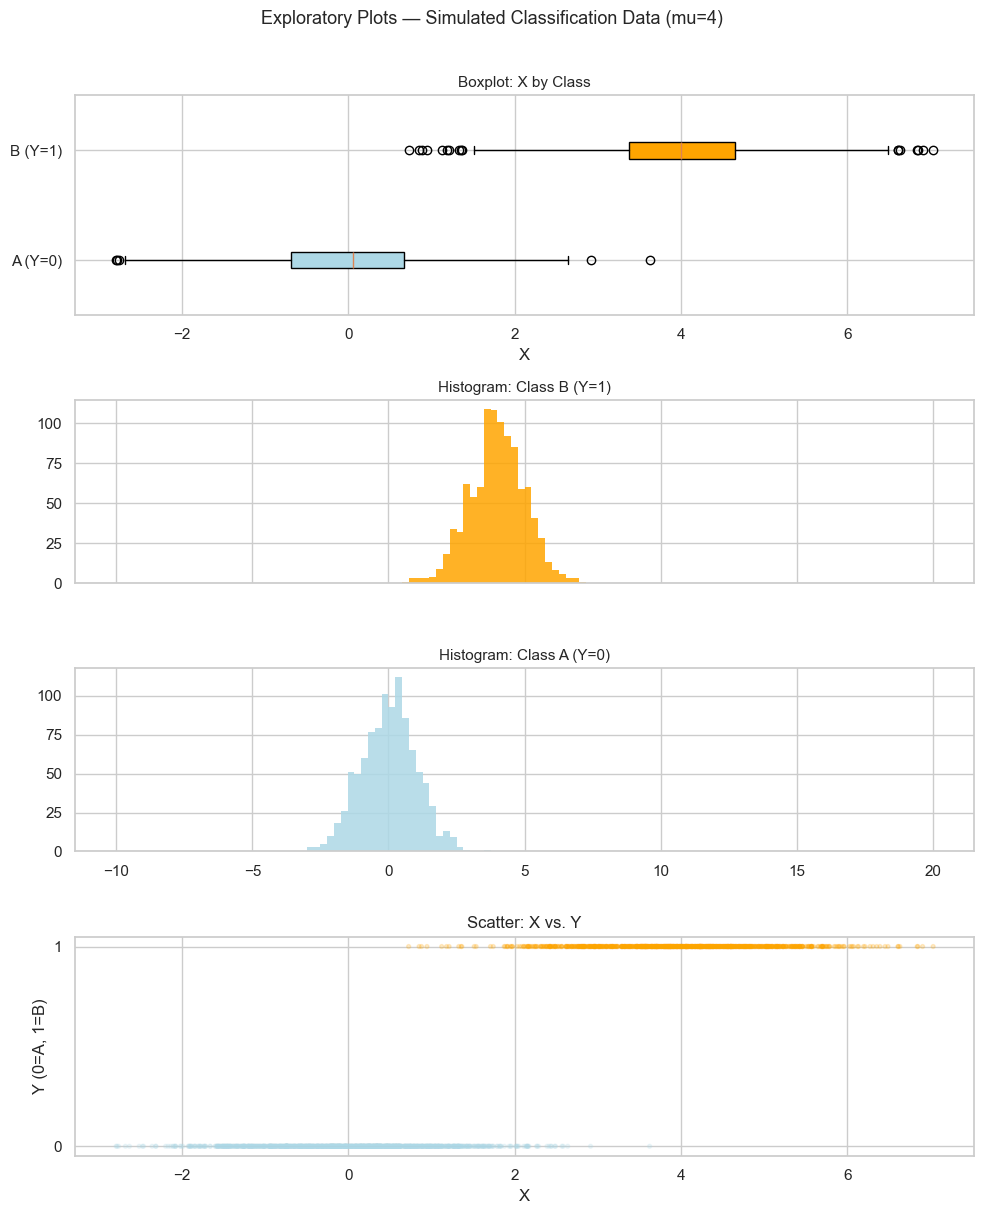

In [6]:
x_A_vals = df['X'][df['Y'] == 0].values
x_B_vals = df['X'][df['Y'] == 1].values
breaks   = np.arange(-10, 20.25, 0.25)

fig, axes = plt.subplots(4, 1, figsize=(10, 12),
                          gridspec_kw={'height_ratios': [1.2, 1, 1, 1.2]})

# Panel 1: Horizontal boxplot — mirrors R: boxplot(x~y, horizontal=T)
bp = axes[0].boxplot([x_A_vals, x_B_vals], vert=False,
                      patch_artist=True,
                      tick_labels=['A (Y=0)', 'B (Y=1)'])  # tick_labels: mpl>=3.9
bp['boxes'][0].set_facecolor('lightblue')   # mirrors R col='lightblue'
bp['boxes'][1].set_facecolor('orange')      # mirrors R col='orange'
axes[0].set_title('Boxplot: X by Class', fontsize=11)
axes[0].set_xlabel('X')

# Panel 2: Histogram for B (orange) — mirrors R: hist(x[y=='B'])
axes[1].hist(x_B_vals, bins=breaks, color='orange', edgecolor='none', alpha=0.85)
axes[1].set_title('Histogram: Class B (Y=1)', fontsize=11)
axes[1].set_xticklabels([])   # mirrors R: xaxt='n'

# Panel 3: Histogram for A (lightblue) — mirrors R: hist(x[y=='A'])
axes[2].hist(x_A_vals, bins=breaks, color='lightblue', edgecolor='none', alpha=0.85)
axes[2].set_title('Histogram: Class A (Y=0)', fontsize=11)

# Panel 4: Scatter X vs Y — mirrors R: plot(x, ifelse(y=='A',0,1), col=...)
colors_scatter = ['lightblue' if yi == 0 else 'orange' for yi in df['Y']]
axes[3].scatter(df['X'], df['Y'], c=colors_scatter, alpha=0.2, s=8)
axes[3].set_xlabel('X')
axes[3].set_ylabel('Y (0=A, 1=B)')
axes[3].set_yticks([0, 1])
axes[3].set_title('Scatter: X vs. Y')

plt.suptitle(f'Exploratory Plots — Simulated Classification Data (mu={mu})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## Linear Discriminant Analysis (LDA)

Mirrors R:
```r
lda.m <- lda(Y~X, data=df)
lda.p <- predict(lda.m)
lda.class <- lda.p$class
table(lda.class, y)
mean(lda.class == y)
```

**Note:** R's `predict(lda.m)` without `newdata` predicts on the training set.
We mirror this exactly — no train/test split — because the purpose here is
to **demonstrate the metrics**, not evaluate generalization.

In [7]:
# Fit LDA — mirrors R: lda(Y~X, data=df)
X_feat = df[['X']]
y_true = df['Y']

lda_m = LinearDiscriminantAnalysis()
lda_m.fit(X_feat, y_true)

print('LDA — Model Summary')
print(f'  Classes      : {lda_m.classes_}')
print(f'  Class priors : {lda_m.priors_}')
print(f'  Group means  : {lda_m.means_.flatten()}')
print(f'  Coefficient  : {lda_m.coef_[0][0]:.6f}')

LDA — Model Summary
  Classes      : [0 1]
  Class priors : [0.5 0.5]
  Group means  : [0.01635845 3.99654462]
  Coefficient  : 3.963921


In [8]:
# Predict on full dataset — mirrors R: predict(lda.m) without newdata
lda_class = lda_m.predict(X_feat)          # mirrors R: lda.p$class
lda_proba = lda_m.predict_proba(X_feat)[:, 1]  # P(Y=1)

# Confusion table — mirrors R: table(lda.class, y)
ct = pd.crosstab(pd.Series(lda_class, name='Predicted'),
                  pd.Series(y_true.values, name='Actual'))
print('Confusion Table (mirrors R: table(lda.class, y))')
print(ct)
print()
print(f'Accuracy: {(lda_class == y_true).mean():.4f}  '
      f'(mirrors R: mean(lda.class == y))')

Confusion Table (mirrors R: table(lda.class, y))
Actual       0    1
Predicted          
0          973   23
1           27  977

Accuracy: 0.9750  (mirrors R: mean(lda.class == y))


## Prediction Metrics

Mirrors R:
```r
lda.metrics <- prediction.metrics(df$Y, lda.class)
print.the.metrics(lda.metrics)
```

In [9]:
# Compute and print metrics — mirrors R: prediction.metrics() + print.the.metrics()
lda_metrics = PredictionMetrics(y_true.values, lda_class)

print('Prediction Metrics — LDA')
print('(mirrors R: print.the.metrics(lda.metrics))')
print()
lda_metrics.print_metrics()

Prediction Metrics — LDA
(mirrors R: print.the.metrics(lda.metrics))

 OBS =   2000   ..................number of observations
 ACC =   0.9750 ..................Accuracy
 TPR =   0.9770 ..................True Positive Rate (Sensitivity)
 TNR =   0.9730 ..................True Negative Rate (Specificity)
 PPV =   0.9731 ..................Positive Predictive Value (Precision)
 NPV =   0.9769 ..................Negative Predictive Value
 FDR =   0.0269 ..................False Discovery Rate
 FPR =   0.0270 ..................False Positive Rate
 F1  =   0.9750 ..................F1 Score (harmonic mean PPV & TPR)
 TP  =    977   ..................True Positives
 TN  =    973   ..................True Negatives
 FP  =     27   ..................False Positives
 FN  =     23   ..................False Negatives
 P   =   1000   ..................Positives (truth)
 N   =   1000   ..................Negatives (truth)


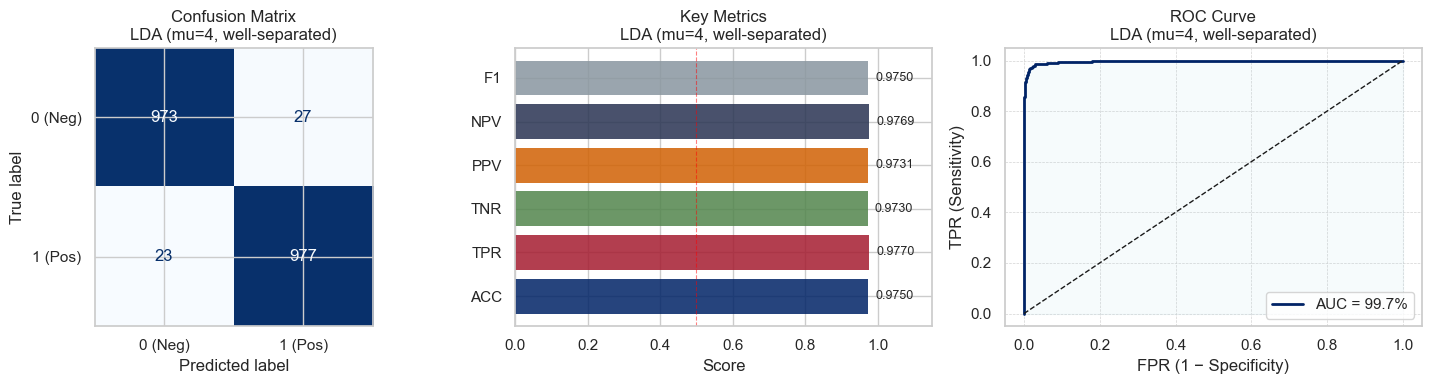

In [10]:
# Metrics dashboard — confusion matrix + bar chart + ROC
plot_metrics_dashboard(lda_metrics,
                        model_name='LDA (mu=4, well-separated)',
                        y_true=y_true.values,
                        y_proba=lda_proba)

## Classification Report

sklearn's extended report — adds F1, support per class.

In [11]:
print('Classification Report (sklearn)')
print(classification_report(y_true, lda_class,
                              target_names=['A (0)', 'B (1)']))

Classification Report (sklearn)
              precision    recall  f1-score   support

       A (0)       0.98      0.97      0.97      1000
       B (1)       0.97      0.98      0.98      1000

    accuracy                           0.97      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.98      0.97      0.97      2000



---

## Metrics DataFrame — Easy Export

The `to_dataframe()` method makes it easy to collect metrics across
multiple models for side-by-side comparison — a pattern used throughout
the `machine_learning/` notebooks.

In [12]:
# Single-row DataFrame — useful for multi-model comparison tables
metrics_df = lda_metrics.to_dataframe()
metrics_df.insert(0, 'Model', 'LDA')
print('Metrics as DataFrame (to_dataframe() method):')
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))

Metrics as DataFrame (to_dataframe() method):
Model  OBS    ACC    TPR    TNR    PPV    NPV    FDR    FPR     F1  TP  TN  FP  FN    P    N
  LDA 2000 0.9750 0.9770 0.9730 0.9731 0.9769 0.0269 0.0270 0.9750 977 973  27  23 1000 1000


---

# Summary

## Key Takeaways

1. **PredictionMetrics is the canonical toolbox class** for binary classification
   metrics. It mirrors the R `prediction.metrics()` function exactly, with two
   bug fixes and three additions: `F1` score, `to_dict()`, and `to_dataframe()`.

2. **mu=4 vs mu=2:** This toolbox uses `mu=4` for clear class separation,
   producing near-perfect metrics that make the formulas easy to verify.
   The `machine_learning/` notebooks use `mu=2` for a more realistic challenge.

3. **Bug fix documented:** The original R `print.the.metrics()` printed
   `metrics$FP` for TP and `metrics$TN` for FP. Both are corrected here.

4. **`plot_metrics_dashboard()`** provides a three-panel visual:
   confusion matrix, metrics bar chart, and ROC curve — a reusable
   diagnostic for any binary classifier.

## R → Python Mapping

| R | Python |
|---|--------|
| `prediction.metrics(truth, predicted)` | `PredictionMetrics(truth, predicted)` |
| `print.the.metrics(metrics)` | `metrics.print_metrics()` |
| `metrics$ACC`, `metrics$TPR`, etc. | `metrics.ACC`, `metrics.TPR`, etc. |
| Named list return | Class attributes + `to_dict()` + `to_dataframe()` |
| `MASS::lda(Y~X, data=df)` | `LinearDiscriminantAnalysis().fit(X, y)` |
| `predict(lda.m)` | `lda_m.predict(X)` |
| `lda.p$class` | `lda_m.predict(X)` |
| `table(lda.class, y)` | `pd.crosstab(predicted, actual)` |
| `mean(lda.class == y)` | `(predicted == y).mean()` |

## References

1. Harvard Elements of Statistical Learning (2021), Dr. Andrey Sivachenko
   and Dr. Victor A. Farutin. Original R `prediction.metrics()` function.
2. Gareth James, et al. *An Introduction to Statistical Learning with
   Applications in R*. Springer. ISBN 978-1-4614-7137-0.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J.
   *An Introduction to Statistical Learning with Applications in Python*.
   Springer, 2023. https://www.statlearning.com